In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import warnings

warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

make_moons is a classic synthetic dataset: two classes that draw interlocking half-moons. *No straight line* can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.

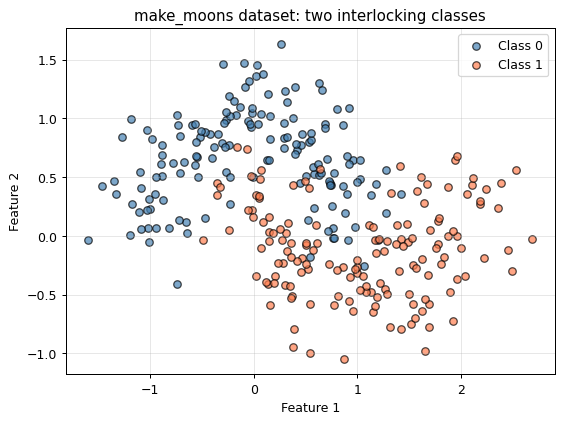

In [2]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', alpha=0.7, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_moons dataset: two interlocking classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.91      0.81      0.86        26
           1       0.86      0.94      0.90        34

    accuracy                           0.88        60
   macro avg       0.89      0.87      0.88        60
weighted avg       0.89      0.88      0.88        60



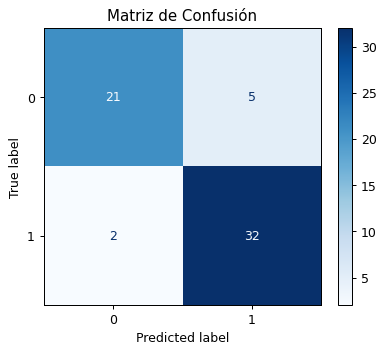

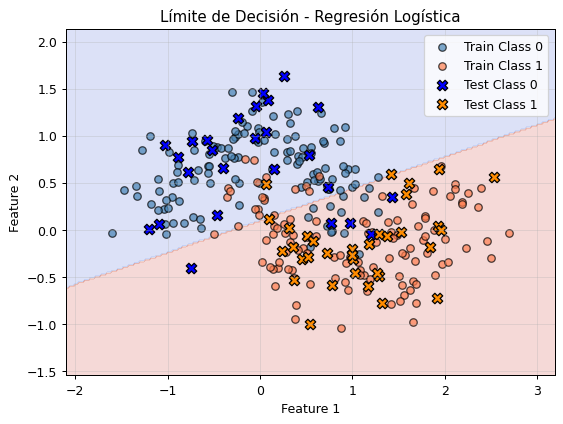

In [7]:
# 1. Crear e instanciar el modelo de Regresión Logística
log_reg = LogisticRegression(random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento
log_reg.fit(X_train, y_train)

# 3. Realizar predicciones sobre el set de prueba
y_pred = log_reg.predict(X_test)

# --- EVALUACIÓN DEL MODELO ---
print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

# Visualizar la Matriz de Confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Matriz de Confusión")
plt.show()

# --- VISUALIZACIÓN DEL LÍMITE DE DECISIÓN ---
# Creamos una malla (mesh) para pintar las regiones de decisión
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predecir para cada punto de la malla
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar el límite de decisión y los puntos
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', label='Train Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', label='Train Class 1', alpha=0.7, edgecolor='k')
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', marker='X', s=70, label='Test Class 0', edgecolor='k')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='darkorange', marker='X', s=70, label='Test Class 1', edgecolor='k')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Límite de Decisión - Regresión Logística')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()